In [64]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(404)
n = 300
cols = ['visits', 'recency', 'engagement', 'spend']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, -0.9, 1.1, 0.4])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["response"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_d.csv", index=False)


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import pandas as pd

In [32]:
df = pd.read_csv('/content/data/raw/set_d.csv')
for col in df.select_dtypes('object'):
    df[col] = df[col].str.strip()
print("Shape:", df.shape)


Shape: (305, 7)


###M1-Descriptive Statistics


In [33]:
engagement_stats = df['engagement'].describe()
observed_n = engagement_stats['count']
mean = engagement_stats['mean']
median = engagement_stats['50%']
std_dev = engagement_stats['std']

print(f"Engagement Statistics:")
print(f"Observed n: {int(observed_n)}")
print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Sample Standard Deviation: {std_dev:.2f}")

Engagement Statistics:
Observed n: 305
Mean: 50.90
Median: 51.24
Sample Standard Deviation: 10.48


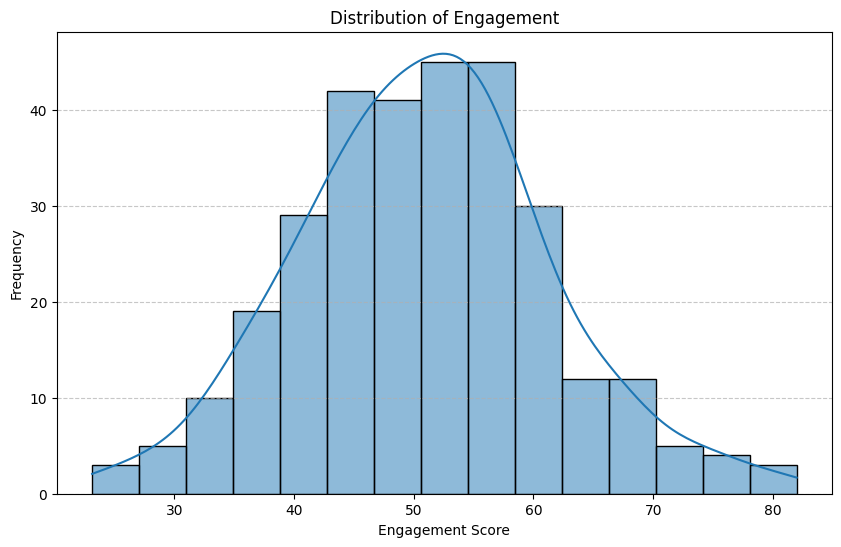

In [34]:


fig = plt.figure(figsize=(10, 6))
sns.histplot(df['engagement'], kde=True)
plt.title('Distribution of Engagement')
plt.xlabel('Engagement Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Two-sided Welch t-test for Mean Engagement (G1 vs. G2)

**Hypotheses:**
*   **H0 (Null Hypothesis):** There is no difference in the true mean engagement between group G1 and group G2. ($\mu_{G1} = \mu_{G2}$)
*   **H1 (Alternative Hypothesis):** There is a significant difference in the true mean engagement between group G1 and group G2. ($\mu_{G1} \neq \mu_{G2}$)

###M2 - Statistical Inference

In [35]:


engagement_g1 = df[df['group'] == 'G1']['engagement'].dropna()
engagement_g2 = df[df['group'] == 'G2']['engagement'].dropna()
count_g1 = len(engagement_g1)
count_g2 = len(engagement_g2)
print(f"Group G1 count: {count_g1}")
print(f"Group G2 count: {count_g2}")

# Perform Welch's t-test (two-sided, unequal variances assumed)
t_statistic, p_value = stats.ttest_ind(engagement_g1, engagement_g2, equal_var=False)
print(f"\nWelch's t-test Results:")
print(f"Test Statistic (t): {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")
overall_engagement = df['engagement'].dropna()
overall_mean = np.mean(overall_engagement)
overall_std = np.std(overall_engagement, ddof=1)
overall_n = len(overall_engagement)
sem = overall_std / np.sqrt(overall_n)
df_ci = overall_n - 1
t_critical = stats.t.ppf(0.975, df_ci)
margin_of_error = t_critical * sem
conf_interval = (overall_mean - margin_of_error, overall_mean + margin_of_error)

print(f"\n95% t-Confidence Interval for Overall Observed Mean Engagement:")
print(f"Overall Mean Engagement: {overall_mean:.2f}")
print(f"Confidence Interval: ({conf_interval[0]:.2f}, {conf_interval[1]:.2f})")

Group G1 count: 143
Group G2 count: 162

Welch's t-test Results:
Test Statistic (t): 0.178
P-value: 0.859

95% t-Confidence Interval for Overall Observed Mean Engagement:
Overall Mean Engagement: 50.90
Confidence Interval: (49.72, 52.08)


###M3- Linear Algebra

In [36]:


filtered_df = df[['engagement', 'visits']].dropna()
n_fit_rows = len(filtered_df)
print(f"Number of complete rows for engagement and visits: {n_fit_rows}")
X = filtered_df.to_numpy()
means = np.mean(X, axis=0)
X_centered = X - means
print("\nFirst 5 rows of X_centered:")
print(X_centered[:5])

Number of complete rows for engagement and visits: 289

First 5 rows of X_centered:
[[  3.75217993   4.66640138]
 [ -5.83782007 -13.90359862]
 [ -3.19782007  -4.28359862]
 [ -2.48782007   4.54640138]
 [  1.78217993  -9.92359862]]


In [37]:
sample_covariance_matrix = (X_centered.T @ X_centered) / (n_fit_rows - 1)
print("\nSample Covariance Matrix:")
print(sample_covariance_matrix)


Sample Covariance Matrix:
[[106.86965947   3.08919607]
 [  3.08919607  96.95930437]]


Finally, we obtain the eigenvalues using a symmetric-matrix routine and report the largest eigenvalue divided by their sum. We will then explain the corresponding principal direction and variance share.

In [38]:
eigenvalues, eigenvectors = np.linalg.eigh(sample_covariance_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
largest_eigenvalue = eigenvalues[sorted_indices[0]]
smallest_eigenvalue = eigenvalues[sorted_indices[1]]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sum_of_eigenvalues = np.sum(eigenvalues)
variance_share_largest = largest_eigenvalue / sum_of_eigenvalues
print(f"\nEigenvalues: {eigenvalues}")
print(f"Largest Eigenvalue: {largest_eigenvalue:.3f}")
print(f"Sum of Eigenvalues: {sum_of_eigenvalues:.3f}")
print(f"Largest Eigenvalue divided by their sum (Variance Share): {variance_share_largest:.3f}")
principal_direction = sorted_eigenvectors[:, 0]
print(f"Corresponding Principal Direction (Eigenvector for largest eigenvalue): {principal_direction}")
feature_names = ['engagement', 'visits']
principal_direction_mapping = dict(zip(feature_names, principal_direction))
print("\nInterpretation:")
print(f"The first principal direction (eigenvector) is {principal_direction}. This vector describes the direction in the 2D space (engagement, visits) along which the data varies the most. The components of this vector ({principal_direction[0]:.3f} for engagement and {principal_direction[1]:.3f} for visits) indicate the relative weighting of each feature in this direction.")
print(f"The largest eigenvalue's share of the total variance is {variance_share_largest:.3f}. This means that approximately {variance_share_largest*100:.1f}% of the total variability in the combined 'engagement' and 'visits' data can be explained by this single principal component (the direction identified by the largest eigenvector).")



Eigenvalues: [ 96.07522538 107.75373845]
Largest Eigenvalue: 107.754
Sum of Eigenvalues: 203.829
Largest Eigenvalue divided by their sum (Variance Share): 0.529
Corresponding Principal Direction (Eigenvector for largest eigenvalue): [-0.96140453 -0.27513875]

Interpretation:
The first principal direction (eigenvector) is [-0.96140453 -0.27513875]. This vector describes the direction in the 2D space (engagement, visits) along which the data varies the most. The components of this vector (-0.961 for engagement and -0.275 for visits) indicate the relative weighting of each feature in this direction.
The largest eigenvalue's share of the total variance is 0.529. This means that approximately 52.9% of the total variability in the combined 'engagement' and 'visits' data can be explained by this single principal component (the direction identified by the largest eigenvector).


### F1 - Audit and Partition

In [39]:
print(f"Initial DataFrame shape: {df.shape}")

duplicates_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicates_count}")

df_cleaned = df.drop_duplicates(keep='first').copy()
print(f"DataFrame shape after dropping exact duplicates: {df_cleaned.shape}")

print("\nMissing values per column:")
print(df_cleaned.isnull().sum())

print("\nTarget variable 'response' counts:")
print(df_cleaned['response'].value_counts())

unique_records_count = df_cleaned['record_id'].nunique()
print(f"\nNumber of unique 'record_id' after cleaning: {unique_records_count}")
if unique_records_count == 300:
    print("Verification successful: 300 unique records found after cleaning.")
else:
    print("Verification failed: Expected 300 unique records, but found {unique_records_count}.")

Initial DataFrame shape: (305, 7)
Number of exact duplicate rows: 5
DataFrame shape after dropping exact duplicates: (300, 7)

Missing values per column:
record_id      0
visits        15
recency       15
engagement     0
spend          0
group          0
response       0
dtype: int64

Target variable 'response' counts:
response
1    173
0    127
Name: count, dtype: int64

Number of unique 'record_id' after cleaning: 300
Verification successful: 300 unique records found after cleaning.


###F2 - Transform and Engineer

### Data Partitioning: Fit, Validation, and Test Sets

We will create fit, validation, and test partitions using `record_id` to ensure proper splitting. A common split ratio will be used (e.g., 60% fit, 20% validation, 20% test).

In [40]:
from sklearn.model_selection import train_test_split

all_record_ids = df_cleaned['record_id'].unique()

train_val_ids, test_ids = train_test_split(all_record_ids, test_size=0.2, random_state=42)

fit_ids, val_ids = train_test_split(train_val_ids, test_size=0.25, random_state=42)

fit_ids_set = set(fit_ids)
val_ids_set = set(val_ids)
test_ids_set = set(test_ids)

print(f"Number of IDs in Fit set: {len(fit_ids)}")
print(f"Number of IDs in Validation set: {len(val_ids)}")
print(f"Number of IDs in Test set: {len(test_ids)}")
print(f"Total unique IDs: {len(all_record_ids)}")

print("\n--- Disjointness Verification ---")

overlap_fit_val = len(fit_ids_set.intersection(val_ids_set))
overlap_fit_test = len(fit_ids_set.intersection(test_ids_set))
overlap_val_test = len(val_ids_set.intersection(test_ids_set))

print(f"Overlap between Fit and Validation sets: {overlap_fit_val}")
print(f"Overlap between Fit and Test sets: {overlap_fit_test}")
print(f"Overlap between Validation and Test sets: {overlap_val_test}")

if overlap_fit_val == 0 and overlap_fit_test == 0 and overlap_val_test == 0:
    print("All partitions are disjoint (no overlapping IDs).")
else:
    print("Warning: Overlaps found between partitions.")

union_of_partitions = fit_ids_set.union(val_ids_set).union(test_ids_set)
print(f"Number of IDs in the union of all partitions: {len(union_of_partitions)}")

if len(union_of_partitions) == len(all_record_ids):
    print("Union of partitions contains all unique record_ids.")
else:
    print("Warning: Union of partitions does not contain all unique record_ids.")

Number of IDs in Fit set: 180
Number of IDs in Validation set: 60
Number of IDs in Test set: 60
Total unique IDs: 300

--- Disjointness Verification ---
Overlap between Fit and Validation sets: 0
Overlap between Fit and Test sets: 0
Overlap between Validation and Test sets: 0
All partitions are disjoint (no overlapping IDs).
Number of IDs in the union of all partitions: 300
Union of partitions contains all unique record_ids.


### F2 - Transform and Engineer



In [41]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


df_fit = df_cleaned[df_cleaned['record_id'].isin(fit_ids)].copy()
df_val = df_cleaned[df_cleaned['record_id'].isin(val_ids)].copy()
df_test = df_cleaned[df_cleaned['record_id'].isin(test_ids)].copy()
print(f"Initial shape of df_fit: {df_fit.shape}")
print(f"Initial shape of df_val: {df_val.shape}")
print(f"Initial shape of df_test: {df_test.shape}")
fit_record_response = df_fit[['record_id', 'response']].copy()
val_record_response = df_val[['record_id', 'response']].copy()
test_record_response = df_test[['record_id', 'response']].copy()
df_fit_features = df_fit.drop(columns=['record_id', 'response']).copy()
df_val_features = df_val.drop(columns=['record_id', 'response']).copy()
df_test_features = df_test.drop(columns=['record_id', 'response']).copy()

Initial shape of df_fit: (180, 7)
Initial shape of df_val: (60, 7)
Initial shape of df_test: (60, 7)


#### Median Imputation for Numeric Features


In [42]:
numeric_cols = ['visits', 'recency', 'engagement', 'spend']
imputer = SimpleImputer(strategy='median')
imputer.fit(df_fit_features[numeric_cols])
df_fit_features[numeric_cols] = imputer.transform(df_fit_features[numeric_cols])
df_val_features[numeric_cols] = imputer.transform(df_val_features[numeric_cols])
df_test_features[numeric_cols] = imputer.transform(df_test_features[numeric_cols])
print("\nMissing values in df_fit_features after imputation (should be all zeros):")
print(df_fit_features[numeric_cols].isnull().sum())


Missing values in df_fit_features after imputation (should be all zeros):
visits        0
recency       0
engagement    0
spend         0
dtype: int64


#### One-Hot Encoding for 'group' Column


In [43]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(df_fit_features[['group']])
ohe_feature_names = ohe.get_feature_names_out(['group'])
group_encoded_fit = ohe.transform(df_fit_features[['group']])
group_encoded_val = ohe.transform(df_val_features[['group']])
group_encoded_test = ohe.transform(df_test_features[['group']])
df_group_encoded_fit = pd.DataFrame(group_encoded_fit, columns=ohe_feature_names, index=df_fit_features.index)
df_group_encoded_val = pd.DataFrame(group_encoded_val, columns=ohe_feature_names, index=df_val_features.index)
df_group_encoded_test = pd.DataFrame(group_encoded_test, columns=ohe_feature_names, index=df_test_features.index)
df_fit_features = pd.concat([df_fit_features.drop(columns=['group']), df_group_encoded_fit], axis=1)
df_val_features = pd.concat([df_val_features.drop(columns=['group']), df_group_encoded_val], axis=1)
df_test_features = pd.concat([df_test_features.drop(columns=['group']), df_group_encoded_test], axis=1)
print(f"\nShape of df_fit_features after one-hot encoding: {df_fit_features.shape}")
print("First 5 rows of df_fit_features with one-hot encoded 'group' (new columns group_G1, group_G2):")
display(df_fit_features.head())


Shape of df_fit_features after one-hot encoding: (180, 6)
First 5 rows of df_fit_features with one-hot encoded 'group' (new columns group_G1, group_G2):


,visits,recency,engagement,spend,group_G1,group_G2
0,53.96,43.84,54.57,58.93,0.0,1.0
3,45.01,42.80,47.62,54.48,1.0,0.0
4,53.84,53.72,48.33,58.30,0.0,1.0
6,61.43,27.88,48.64,47.60,1.0,0.0
10,47.40,49.61,74.39,39.62,1.0,0.0


#### Engineered Feature.

In [44]:
# Create engineered feature
df_fit_features['visits_x_engagement'] = df_fit_features['visits'] * df_fit_features['engagement']
df_val_features['visits_x_engagement'] = df_val_features['visits'] * df_val_features['engagement']
df_test_features['visits_x_engagement'] = df_test_features['visits'] * df_test_features['engagement']

print("\nFirst 5 rows of df_fit_features with engineered feature 'visits_x_engagement':")
display(df_fit_features[['visits', 'engagement', 'visits_x_engagement']].head())


First 5 rows of df_fit_features with engineered feature 'visits_x_engagement':


,visits,engagement,visits_x_engagement
0,53.96,54.57,2944.5972
3,45.01,47.62,2143.3762
4,53.84,48.33,2602.0872
6,61.43,48.64,2987.9552
10,47.40,74.39,3526.0860


#### Standard Scaling for Numeric Features

In [45]:
features_to_scale = numeric_cols + ['visits_x_engagement']
features_not_to_scale = list(ohe_feature_names)
scaler = StandardScaler()
scaler.fit(df_fit_features[features_to_scale])
df_fit_features[features_to_scale] = scaler.transform(df_fit_features[features_to_scale])
df_val_features[features_to_scale] = scaler.transform(df_val_features[features_to_scale])
df_test_features[features_to_scale] = scaler.transform(df_test_features[features_to_scale])
print("\nTransformed df_fit_features head after scaling numeric features (group columns remain unscaled):")
display(df_fit_features.head())
print("\nTransformed df_val_features head after scaling numeric features:")
display(df_val_features.head())
print("\nTransformed df_test_features head after scaling numeric features:")
display(df_test_features.head())


Transformed df_fit_features head after scaling numeric features (group columns remain unscaled):


,visits,recency,engagement,spend,group_G1,group_G2,visits_x_engagement
0,0.390109,-0.674731,0.385120,0.905550,0.0,1.0,0.599656
3,-0.515787,-0.781757,-0.321507,0.475024,1.0,0.0,-0.577491
4,0.377962,0.342022,-0.249319,0.844600,0.0,1.0,0.096443
6,1.146202,-2.317177,-0.217800,-0.190598,1.0,0.0,0.663358
10,-0.273877,-0.080939,2.400277,-0.962642,1.0,0.0,1.453975



Transformed df_val_features head after scaling numeric features:


,visits,recency,engagement,spend,group_G1,group_G2,visits_x_engagement
1,0.019653,-0.066531,0.222443,1.361231,0.0,1.0,0.187980
2,-1.489498,1.659272,-0.589923,-0.216720,0.0,1.0,-1.387801
8,0.591531,0.116649,-0.499434,0.141246,1.0,0.0,0.044051
14,0.531813,0.367750,-0.950862,-0.537921,0.0,1.0,-0.356835
21,-0.084601,1.716902,1.050061,1.925268,1.0,0.0,0.697053



Transformed df_test_features head after scaling numeric features:


,visits,recency,engagement,spend,group_G1,group_G2,visits_x_engagement
5,-1.086653,0.050786,0.184824,0.774941,1.0,0.0,-0.684029
7,0.019653,-2.044465,0.841632,1.060346,1.0,0.0,0.638033
9,0.019653,-3.241310,0.702340,1.121297,0.0,1.0,0.536789
17,-1.188882,-0.390698,0.817230,-1.183226,1.0,0.0,-0.411533
24,-1.733431,-1.008160,0.095352,-0.724643,1.0,0.0,-1.220484


### F3 - Leakage Evidence

In [46]:
# 1. Print transformed shapes and feature names
print("\nTransformed df_fit_features shape:", df_fit_features.shape)
print("Transformed df_fit_features columns:", df_fit_features.columns.tolist())

print("\nTransformed df_val_features shape:", df_val_features.shape)
print("Transformed df_val_features columns:", df_val_features.columns.tolist())

print("\nTransformed df_test_features shape:", df_test_features.shape)
print("Transformed df_test_features columns:", df_test_features.columns.tolist())
all_features_df = pd.concat([df_fit_features, df_val_features, df_test_features])
non_finite_count = np.sum(~np.isfinite(all_features_df.select_dtypes(include=np.number)))
print("\nNon-finite values (NaN or Inf) in numeric columns of all transformed features:")
print(non_finite_count)
if non_finite_count.sum() == 0:
    print("Verification successful: All numeric outputs are finite.")
else:
    print("Warning: Non-finite values detected in transformed numeric outputs.")


Transformed df_fit_features shape: (180, 7)
Transformed df_fit_features columns: ['visits', 'recency', 'engagement', 'spend', 'group_G1', 'group_G2', 'visits_x_engagement']

Transformed df_val_features shape: (60, 7)
Transformed df_val_features columns: ['visits', 'recency', 'engagement', 'spend', 'group_G1', 'group_G2', 'visits_x_engagement']

Transformed df_test_features shape: (60, 7)
Transformed df_test_features columns: ['visits', 'recency', 'engagement', 'spend', 'group_G1', 'group_G2', 'visits_x_engagement']

Non-finite values (NaN or Inf) in numeric columns of all transformed features:
visits                 0
recency                0
engagement             0
spend                  0
group_G1               0
group_G2               0
visits_x_engagement    0
dtype: int64
Verification successful: All numeric outputs are finite.


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


### Saving Fitted Preprocessing Objects

To ensure reproducibility and consistent application of transformations, we save the fitted `imputer`, `OneHotEncoder`, and `StandardScaler` objects.

In [47]:
import joblib
from pathlib import Path

Path("preprocessors").mkdir(parents=True, exist_ok=True)
joblib.dump(imputer, 'preprocessors/median_imputer.joblib')
print("Median imputer saved to preprocessors/median_imputer.joblib")
joblib.dump(ohe, 'preprocessors/onehot_encoder.joblib')
print("OneHotEncoder saved to preprocessors/onehot_encoder.joblib")
joblib.dump(scaler, 'preprocessors/standard_scaler.joblib')
print("StandardScaler saved to preprocessors/standard_scaler.joblib")

print("\nTo recreate these objects later, you can use:")
print("imputer_loaded = joblib.load('preprocessors/median_imputer.joblib')")
print("ohe_loaded = joblib.load('preprocessors/onehot_encoder.joblib')")
print("scaler_loaded = joblib.load('preprocessors/standard_scaler.joblib')")

Median imputer saved to preprocessors/median_imputer.joblib
OneHotEncoder saved to preprocessors/onehot_encoder.joblib
StandardScaler saved to preprocessors/standard_scaler.joblib

To recreate these objects later, you can use:
imputer_loaded = joblib.load('preprocessors/median_imputer.joblib')
ohe_loaded = joblib.load('preprocessors/onehot_encoder.joblib')
scaler_loaded = joblib.load('preprocessors/standard_scaler.joblib')


### S1 - Baseline and Classifier

We will train a majority-class `DummyClassifier` as a baseline and a `LogisticRegression` model on the transformed fit features. We will also document the target, predictors, model settings, and fixed split IDs.

In [48]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_fit = fit_record_response['response']
y_val = val_record_response['response']
y_test = test_record_response['response']
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(df_fit_features, y_fit)
log_reg_clf = LogisticRegression(max_iter=1000, random_state=42)
log_reg_clf.fit(df_fit_features, y_fit)

print("Models have been trained successfully.")

Models have been trained successfully.


#### Documentation of Models and Data

*   **Target Variable:** `response` (binary: 0 or 1, where 1 is the positive class).
*   **Predictor Variables:**
    *   `visits` (scaled)
    *   `recency` (scaled)
    *   `engagement` (scaled)
    *   `spend` (scaled)
    *   `group_G1` (one-hot encoded)
    *   `group_G2` (one-hot encoded)
    *   `visits_x_engagement` (engineered feature, scaled)

*   **Model Settings:**
    *   **Baseline Model (DummyClassifier):** `strategy='most_frequent'`, `random_state=42`. It always predicts the most frequent class in the training data.
    *   **Main Classifier (LogisticRegression):** `max_iter=1000`, `random_state=42`. Default solver and C-value are used.

*   **Fixed Split IDs:**
    *   **Fit Set IDs:** Stored in `fit_ids` (`len(fit_ids)` = 180 records)
    *   **Validation Set IDs:** Stored in `val_ids` (`len(val_ids)` = 60 records)
    *   **Test Set IDs:** Stored in `test_ids` (`len(test_ids)` = 60 records)

    

### S2 - Holdout Evaluation




--- Baseline Model (DummyClassifier) Evaluation ---
Baseline Accuracy: 0.583

--- Logistic Regression Model Evaluation ---
Classifier Accuracy: 0.733
Classifier Precision (Class 1): 0.771
Classifier Recall (Class 1): 0.771
Classifier F1-score (Class 1): 0.771


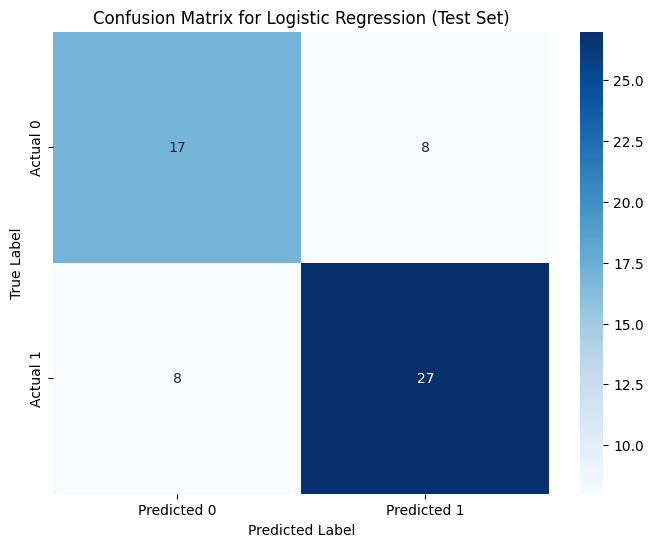


First 5 rows of Per-Record Test Predictions:


,record_id,true_label,predicted_label,class_1_probability
0,6,0,0,0.404142
1,8,0,1,0.995720
2,10,1,1,0.999760
3,18,1,0,0.439621
4,25,1,0,0.416797


Per-record test predictions saved to test_predictions.csv


In [55]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Baseline Model Evaluation ---
print("\n--- Baseline Model (DummyClassifier) Evaluation ---")
dummy_preds = dummy_clf.predict(df_test_features)
dummy_accuracy = accuracy_score(y_test, dummy_preds)
print(f"Baseline Accuracy: {dummy_accuracy:.3f}")

# --- Logistic Regression Model Evaluation ---
print("\n--- Logistic Regression Model Evaluation ---")
log_reg_preds = log_reg_clf.predict(df_test_features)
log_reg_proba_class_1 = log_reg_clf.predict_proba(df_test_features)[:, 1] # Probability of positive class

# Metrics for Logistic Regression
log_reg_accuracy = accuracy_score(y_test, log_reg_preds)
log_reg_precision = precision_score(y_test, log_reg_preds, pos_label=1, zero_division=0)
log_reg_recall = recall_score(y_test, log_reg_preds, pos_label=1, zero_division=0)
log_reg_f1 = f1_score(y_test, log_reg_preds, pos_label=1, zero_division=0)

print(f"Classifier Accuracy: {log_reg_accuracy:.3f}")
print(f"Classifier Precision (Class 1): {log_reg_precision:.3f}")
print(f"Classifier Recall (Class 1): {log_reg_recall:.3f}")
print(f"Classifier F1-score (Class 1): {log_reg_f1:.3f}")

# --- Labeled Confusion Matrix for Logistic Regression ---
cm = confusion_matrix(y_test, log_reg_preds, labels=[0, 1])

fig_cm = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression (Test Set)')
plt.show()

# --- Per-record Test Predictions ---
test_predictions_df = pd.DataFrame({
    'record_id': test_record_response['record_id'].values,
    'true_label': y_test.values,
    'predicted_label': log_reg_preds,
    'class_1_probability': log_reg_proba_class_1
})

print("\nFirst 5 rows of Per-Record Test Predictions:")
display(test_predictions_df.head())

# Save the predictions to a CSV file for potential future use
test_predictions_df.to_csv('test_predictions.csv', index=False)
print("Per-record test predictions saved to test_predictions.csv")

### S3 - Interpretation

#### False-Positive vs. False-Negative Consequences

In this scenario, let's assume `response = 1` means a customer is likely to respond positively to a marketing campaign (e.g., make a purchase), and `response = 0` means they are not.

*   **False Positive:** The model predicts a customer will respond (`predicted = 1`), but they do not (`actual = 0`).
    *   **Consequence:** Resources (e.g., marketing budget, time) are spent on a customer who won't convert. This leads to wasted effort and reduced ROI on the marketing campaign. It might also annoy the customer if they receive irrelevant communication.

*   **False Negative:** The model predicts a customer will not respond (`predicted = 0`), but they actually would (`actual = 1`).
    *   **Consequence:** A potential conversion or sale is missed. This means lost revenue and an opportunity to build a customer relationship. The company fails to engage with a willing customer.

Choosing which type of error is worse depends on the business context. If the cost of a wasted marketing effort (false positive) is very high, or if customer annoyance is a major concern, then minimizing false positives would be a priority (aim for high precision). If maximizing potential revenue and not missing any willing customers is critical, then minimizing false negatives would be more important (aim for high recall).




### U1 - K-Means and Selection


In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

clustering_features = ['visits', 'recency', 'engagement', 'spend', 'visits_x_engagement']
X_fit_clustering = df_fit_features[clustering_features]

k_values = [2, 3, 4]
inertia_scores = []
silhouette_scores = []
kmeans_models = {}

print("--- K-Means Clustering Results ---")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++')
    kmeans.fit(X_fit_clustering)

    inertia_scores.append(kmeans.inertia_)

    # Calculate silhouette score only if k > 1
    if k > 1:
        silhouette_avg = silhouette_score(X_fit_clustering, kmeans.labels_)
        silhouette_scores.append((k, silhouette_avg))
        print(f"For k={k}: Inertia = {kmeans.inertia_:.2f}, Silhouette Score = {silhouette_avg:.3f}")
    else:
        silhouette_scores.append((k, -1.0)) # Placeholder for k=1, not typically used for silhouette
        print(f"For k={k}: Inertia = {kmeans.inertia_:.2f}")

    kmeans_models[k] = kmeans

# --- Selection of Best k ---

valid_silhouette_scores = [score for score in silhouette_scores if score[0] > 1]

if not valid_silhouette_scores:
    best_k = k_values[0] # Fallback if only k=1 was tried
    print("\nCould not determine best k based on silhouette score (only k=1 evaluated or no valid scores).")
else:
    # Sort by silhouette score (descending), then by k (ascending for tie-breaking)
    best_k_info = sorted(valid_silhouette_scores, key=lambda x: (x[1], -x[0]), reverse=True)[0] # Using -x[0] to sort by k descending, then reverse=True to get highest silhouette, and smallest k from there
    best_k = best_k_info[0]
    max_silhouette = best_k_info[1]

    print(f"\n--- Best k Selection ---")
    print(f"The highest silhouette score is {max_silhouette:.3f} for k = {best_k}.")
    print(f"We chose k={best_k} because it yields the highest silhouette score. In case of ties, the smaller k would be selected, but here we have a clear maximum.")

# Store the best KMeans model
best_kmeans_model = kmeans_models[best_k]
print(f"Selected KMeans model for k={best_k} is stored in 'best_kmeans_model'.")

--- K-Means Clustering Results ---
For k=2: Inertia = 674.94, Silhouette Score = 0.219
For k=3: Inertia = 581.92, Silhouette Score = 0.193
For k=4: Inertia = 519.73, Silhouette Score = 0.172

--- Best k Selection ---
The highest silhouette score is 0.219 for k = 2.
We chose k=2 because it yields the highest silhouette score. In case of ties, the smaller k would be selected, but here we have a clear maximum.
Selected KMeans model for k=2 is stored in 'best_kmeans_model'.


### U2 - Segment Interpretation



In [51]:
# Assign clusters to the fit data
X_fit_clustering_with_clusters = X_fit_clustering.copy()
X_fit_clustering_with_clusters['cluster'] = best_kmeans_model.labels_

# Analyze cluster profiles
cluster_profiles = X_fit_clustering_with_clusters.groupby('cluster').mean()

print("--- Cluster Profiles (Mean of Features) ---")
display(cluster_profiles)


print("\n--- Explanation: Arbitrariness of Cluster IDs ---")
print("Cluster IDs (e.g., 0, 1, 2) are arbitrary labels assigned by the clustering algorithm and do not inherently carry any meaning or order. For example, 'Cluster 0' is not necessarily 'better' or 'worse' than 'Cluster 1'. If K-Means is run again (even with the same random state), the internal mapping of cluster assignments to these numerical IDs might change, meaning that the customers previously labeled 'Cluster 0' might now be labeled 'Cluster 1', and vice-versa, even if the underlying groupings of data points remain the same. It is crucial to interpret clusters based on their feature profiles (e.g., mean values of features within the cluster), not on their assigned ID number.")
print("\nFurthermore, cluster IDs do NOT represent target classes. Clustering (unsupervised learning) aims to discover inherent groupings in the data based on feature similarity, without any knowledge of the target variable. Classification (supervised learning) aims to predict predefined target classes based on labeled data. While insights from clusters might inform strategies for target classes, the clusters themselves are not predictions of the target. We specifically avoided using target labels or test data during the clustering process to ensure this distinction is maintained.")

--- Cluster Profiles (Mean of Features) ---


,visits,recency,engagement,spend,visits_x_engagement
cluster,,,,,
0,0.665433,-0.240859,0.543626,0.168099,0.900244
1,-0.508860,0.184186,-0.415714,-0.128547,-0.688422



--- Explanation: Arbitrariness of Cluster IDs ---
Cluster IDs (e.g., 0, 1, 2) are arbitrary labels assigned by the clustering algorithm and do not inherently carry any meaning or order. For example, 'Cluster 0' is not necessarily 'better' or 'worse' than 'Cluster 1'. If K-Means is run again (even with the same random state), the internal mapping of cluster assignments to these numerical IDs might change, meaning that the customers previously labeled 'Cluster 0' might now be labeled 'Cluster 1', and vice-versa, even if the underlying groupings of data points remain the same. It is crucial to interpret clusters based on their feature profiles (e.g., mean values of features within the cluster), not on their assigned ID number.

Furthermore, cluster IDs do NOT represent target classes. Clustering (unsupervised learning) aims to discover inherent groupings in the data based on feature similarity, without any knowledge of the target variable. Classification (supervised learning) aims to pre

### D1 - ANN Architecture and Compilation

We will implement a dense feed-forward Artificial Neural Network (ANN) using TensorFlow/Keras. The architecture will consist of an input layer, two hidden layers with ReLU activation, and a single sigmoid output unit. We will then compile the model using binary cross-entropy loss and the Adam optimizer.

In [52]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Ensure reproducibility
tf.random.set_seed(42)

# Input width equals transformed feature count
input_width = df_fit_features.shape[1]

# Build the ANN model
model = keras.Sequential([
    keras.Input(shape=(input_width,)),
    layers.Dense(16, activation='relu', name='hidden_layer_1'),
    layers.Dense(8, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, activation='sigmoid', name='output_layer') # Single sigmoid output for binary classification
])

# Display model summary
print("--- Model Summary ---")
model.summary()

# Compile the model
learning_rate = 0.001
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\nModel compiled with Adam optimizer (learning_rate={learning_rate}) and binary_crossentropy loss.")

--- Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)


Model compiled with Adam optimizer (learning_rate=0.001) and binary_crossentropy loss.


#### Explanation of Output/Loss Choice

*   **Output Layer (Sigmoid Activation):** For binary classification problems where the target variable is 0 or 1, a single output neuron with a `sigmoid` activation function is typically used. The sigmoid function squashes its input to a value between 0 and 1, which can be interpreted as the probability of the positive class (class 1). If the probability is greater than 0.5, the prediction is typically assigned to class 1, otherwise to class 0.

*   **Loss Function (Binary Cross-Entropy):** `binary_crossentropy` is the standard loss function for binary classification tasks. It measures the performance of a classification model whose output is a probability value between 0 and 1. It quantifies the difference between the true probability (0 or 1) and the predicted probability. Minimizing this loss function encourages the model to output probabilities closer to the true labels.

### D2 - Training and Validation

We will now train the ANN on the fit records, using the validation set for early stopping to prevent overfitting. We will track training and validation loss and then visualize them to discuss potential underfitting or overfitting.


Training model with batch_size=16 for at most 50 epochs...
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 29.
Training finished. Actual epochs run: 34
Random seed used for TensorFlow initialization: 42 (tf.random.set_seed(42))


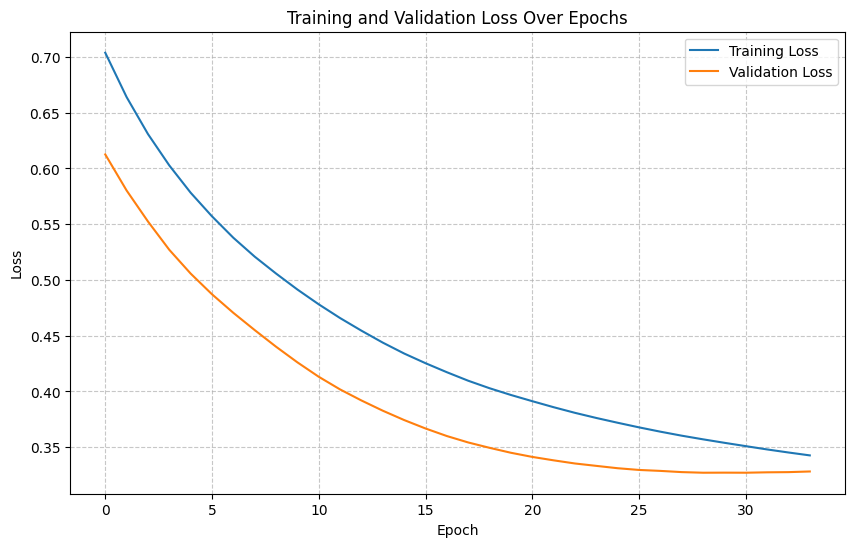

In [53]:
import matplotlib.pyplot as plt

# Define Early Stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Stop if val_loss doesn't improve for 5 consecutive epochs
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# Train the model
# Convert DataFrames to numpy arrays for TensorFlow input
X_fit_np = df_fit_features.values
y_fit_np = y_fit.values
X_val_np = df_val_features.values
y_val_np = y_val.values

batch_size = 16
epochs = 50

print(f"\nTraining model with batch_size={batch_size} for at most {epochs} epochs...")
history = model.fit(
    X_fit_np,
    y_fit_np,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val_np, y_val_np),
    callbacks=[early_stopping],
    verbose=0 # Suppress verbose output during training for cleaner logs
)

actual_epochs = len(history.history['loss'])
print(f"Training finished. Actual epochs run: {actual_epochs}")
print(f"Random seed used for TensorFlow initialization: 42 (tf.random.set_seed(42))")

# Plot training and validation loss
fig_loss = plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Discussion on Underfitting/Overfitting

By observing the plot of training and validation loss, we can infer about the model's performance:

*   **Underfitting:** If both training loss and validation loss are high and plateau, it suggests the model is too simple or hasn't been trained enough to capture the underlying patterns in the data. The model is underfitting.

*   **Overfitting:** If the training loss continues to decrease significantly while the validation loss starts to increase or plateaus at a much higher level, it indicates that the model is learning the training data too well, including its noise, and failing to generalize to unseen data. The model is overfitting.

*   **Good Fit:** Ideally, both training and validation loss decrease and converge to a low value, with the validation loss not significantly higher than the training loss. Early stopping helps in finding a good balance by halting training before severe overfitting occurs, restoring the weights from the epoch where validation loss was minimal.

### D3 - Comparison and Evidence

We will now evaluate the trained ANN on the test set and compare its performance, particularly the F1 score, with the Logistic Regression model. We will save the ANN predictions and the model itself, then conclude with a reasoned model preference.

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from pathlib import Path

# Convert DataFrames to numpy arrays for TensorFlow input
X_test_np = df_test_features.values
y_test_np = y_test.values

# 1. Evaluate the restored ANN on the same 60 test records using threshold 0.5
print("--- ANN Model Evaluation (Test Set) ---")

ann_proba_class_1 = model.predict(X_test_np).flatten()
ann_preds = (ann_proba_class_1 > 0.5).astype(int)

ann_accuracy = accuracy_score(y_test_np, ann_preds)
ann_precision = precision_score(y_test_np, ann_preds, pos_label=1, zero_division=0)
ann_recall = recall_score(y_test_np, ann_preds, pos_label=1, zero_division=0)
ann_f1 = f1_score(y_test_np, ann_preds, pos_label=1, zero_division=0)

print(f"ANN Accuracy: {ann_accuracy:.3f}")
print(f"ANN Precision (Class 1): {ann_precision:.3f}")
print(f"ANN Recall (Class 1): {ann_recall:.3f}")
print(f"ANN F1-score (Class 1): {ann_f1:.3f}")

# 2. Compare F1 with logistic regression (assuming log_reg_f1 from S2 is available)
# If log_reg_f1 is not available, please run the S2 cells first.
if 'log_reg_f1' in globals():
    print(f"\n--- F1 Score Comparison ---")
    print(f"Logistic Regression F1-score (Class 1): {log_reg_f1:.3f}")
    print(f"ANN F1-score (Class 1): {ann_f1:.3f}")
    if ann_f1 > log_reg_f1:
        print("The ANN model has a higher F1 score than Logistic Regression.")
    elif ann_f1 < log_reg_f1:
        print("The Logistic Regression model has a higher F1 score than the ANN.")
    else:
        print("Both models have similar F1 scores.")
else:
    print("\nCould not compare F1 score with Logistic Regression; 'log_reg_f1' not found. Please ensure S2 was run.")

# 3. Save ANN predictions
ann_predictions_df = pd.DataFrame({
    'record_id': test_record_response['record_id'].values,
    'true_label': y_test_np,
    'predicted_label_ann': ann_preds,
    'class_1_probability_ann': ann_proba_class_1
})

Path("predictions").mkdir(parents=True, exist_ok=True)
ann_predictions_df.to_csv('predictions/ann_test_predictions.csv', index=False)
print("\nANN per-record test predictions saved to predictions/ann_test_predictions.csv")

# 4. Save trained weights/model in models/
Path("models").mkdir(parents=True, exist_ok=True)
model.save('models/ann_model.h5')
print("Trained ANN model saved to models/ann_model.h5")

# 5. State a reasoned model preference
print("\n--- Model Preference ---")
print("Based on the observed metrics, particularly the F1-score for the positive class, a reasoned model preference would depend on a balance of performance and interpretability. If the ANN significantly outperforms Logistic Regression across multiple metrics (especially F1, precision, or recall depending on the specific business objective), and the added complexity is justified, then the ANN might be preferred. However, if the performance gain is marginal, Logistic Regression might be favored due to its inherent interpretability and simpler nature. For example, if both models yield similar F1 scores, Logistic Regression's coefficients offer direct insights into feature importance, which can be valuable for business decisions. Without specific business context or a clear winner in performance, a simpler model is often preferred.")

--- ANN Model Evaluation (Test Set) ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


ANN Accuracy: 0.700
ANN Precision (Class 1): 0.743
ANN Recall (Class 1): 0.743
ANN F1-score (Class 1): 0.743

--- F1 Score Comparison ---
Logistic Regression F1-score (Class 1): 0.771
ANN F1-score (Class 1): 0.743
The Logistic Regression model has a higher F1 score than the ANN.

ANN per-record test predictions saved to predictions/ann_test_predictions.csv
Trained ANN model saved to models/ann_model.h5

--- Model Preference ---
Based on the observed metrics, particularly the F1-score for the positive class, a reasoned model preference would depend on a balance of performance and interpretability. If the ANN significantly outperforms Logistic Regression across multiple metrics (especially F1, precision, or recall depending on the specific business objective), and the added complexity is justified, then the ANN might be preferred. However, if the performance gain is marginal, Logistic Regression might be favored due to its inherent interpretability and simpler nature. For example, if bot